In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

# =========================================================================
# 【步驟 1】主路徑與受試者分組配置
# =========================================================================
# 💡 請確認這是你的 Linux / WSL 實際主路徑
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

# 精確分組名單
hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']

all_erp_records = []

# =========================================================================
# 【步驟 2】遍歷 BIDS 資料夾，讀取真實 .set 檔案並進行預處理
# =========================================================================
# 使用萬用字元自動搜尋所有受試者 eeg 資料夾底下的 .set 檔案
search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.set")
file_list = glob.glob(search_path)

if not file_list:
    raise FileNotFoundError(f"❌ 在路徑 {data_dir} 下找不到任何 .set 檔案，請檢查路徑或權限！")

print(f"🔍 成功偵測到 {len(file_list)} 個受試者腦波檔案，開始進入 0.1-30Hz 預處理管線...\n")

for file_path in sorted(file_list):
    # 從檔名中抽取出受試者編號 (例如: sub-006)
    sub_str = os.path.basename(file_path).split('_')[0]
    
    # 判斷這名受試者屬於哪一組，若都不在則跳過（中間 40% 排除）
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  # 跳過不分析
        
    print(f"🧠 正在處理: {sub_str} ({group_label})")
    
    try:
        # 1. 讀取 EEGLAB .set 原始檔案 (preload=True 代表直接載入記憶體以便濾波)
        raw = mne.io.read_raw_eeglab(file_path, preload=True, verbose=False)
        
        # 2. 🎛️ 執行經典 P300 帶通濾波器 (High-pass: 0.1 Hz, Low-pass: 30.0 Hz)
        # fir_design='firwin' 是 MNE 預設且穩健的有限脈衝響應濾波器設計
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        
        # 3. 擷取事件標記 (Events)
        events, event_id = mne.events_from_annotations(raw, verbose=False)
        
        # 🎯 【核心微調點】請檢查你的實驗 Trigger 叫什麼名字。
        # 這裡假設你的 Target 刺激在資料裡的名稱包含 'Stimulus' 或特定數字。
        # 如果不確定，可以在這裡列印 print(event_id) 檢查
        target_keys = [k for k in event_id.keys() if 'target' in k.lower() or 'S  1' in k]
        if not target_keys:
            # 如果找不到特定關鍵字，預設使用第一個事件標記
            target_keys = [list(event_id.keys())[0]]
            
        include_events = {k: event_id[k] for k in target_keys}
        
        # 4. 🔪 切出 Epochs (-200ms 到 800ms) 並進行基線校正 (Baseline Correction)
        epochs = mne.Epochs(
            raw, events, event_id=include_events, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        # 5. 抓取 Pz 電極點的資料並計算平均波形 (Evoked / Grand Average)
        # 如果你的資料沒有 Pz，可以換成 'Cz' 或 'EEG 015' 等
        if 'Pz' in epochs.ch_names:
            target_ch = 'Pz'
        else:
            # 若無標準導極名稱，選取中間區域的電極點
            target_ch = epochs.ch_names[len(epochs.ch_names)//2]
            
        evoked_data = epochs.average(picks=target_ch).data[0] * 1e6  # 換算成微伏 (uV)
        times = epochs.times
        
        # 6. 將每個時間點的電壓值存入 master 記錄表中
        for t_idx, t in enumerate(times):
            all_erp_records.append({
                'Subject': sub_str,
                'Group': group_label,
                'Time': t,
                'Amplitude': evoked_data[t_idx]
            })
            
    except Exception as e:
        print(f"⚠️ 讀取 {sub_str} 時發生錯誤: {e}")

df_real_erp = pd.DataFrame(all_erp_records)
print("\n✅ 所有真實受試者數據讀取暨 0.1-30Hz 濾波完畢！開始繪圖...")

# =========================================================================
# 【步驟 3】🎨 繪製真實數據的 Grand Average ERP 波形圖
# =========================================================================
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.set_theme(style="white")

# A. 繪製全體總平均背景線
sns.lineplot(
    data=df_real_erp, x='Time', y='Amplitude', 
    color='#7f8c8d', linewidth=2, linestyle='--', label='Grand Average (All)',
    errorbar=None, alpha=0.5, ax=ax
)

# B. 繪製 HWM (紅色) 與 LWM (綠色) 的真實 ERP 與 SEM 陰影區
sns.lineplot(
    data=df_real_erp, x='Time', y='Amplitude', hue='Group',
    palette={'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'},
    linewidth=4, errorbar='se', alpha=0.9, ax=ax
)

# C. 標注科學指標線
plt.axvline(0, color='black', linestyle='-', linewidth=1.5)  # Onset
plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)  # 0 uV
plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.12, label='P300 Window (300-550 ms)')

# D. 換算毫秒與視覺美化
plt.title("EEG Neurophysiological Evidence: Real P300 Waveform Comparison", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
plt.ylabel("Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
plt.xlim(-0.2, 0.8)

x_ticks = np.arange(-0.2, 0.9, 0.1)
plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
sns.despine(trim=True)

plt.tight_layout()
plt.savefig('p300_real_data_comparison.png', dpi=300, bbox_inches='tight')
print("💾 【大功告成】真實數據版 P300 波形圖已成功儲存為: p300_real_data_comparison.png")
plt.show()

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

# =========================================================================
# 【步驟 1】主路徑與受試者分組配置
# =========================================================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']

all_erp_records = []

# =========================================================================
# 【步驟 2】BrainVision 預處理管線 (尊重 Online Reference)
# =========================================================================
# 💡 關鍵修改：BrainVision 格式只需搜尋標頭檔 (.vhdr)，MNE 會自動關聯 .eeg 與 .vmrk
search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

if not file_list:
    raise FileNotFoundError(f"❌ 找不到任何 .vhdr 檔案，請檢查路徑是否包含該檔案：{data_dir}")

print(f"🔍 偵測到 {len(file_list)} 個 BrainVision 檔案，直接沿用 Online Reference 並進行 0.1-30Hz 濾波...\n")

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  # 跳過不分析中間 40%
        
    print(f"🧠 正在預處理: {sub_str} ({group_label})")
    
    try:
        # 1. 💡 核心修改：使用 MNE 的 read_raw_brainvision 讀取格式
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        # 2. 告訴 MNE 該檔案已做過 Online Reference，跳過內部參考點安全性檢查
        raw.info['custom_ref_applied'] = int(mne.io.constants.FIFF.FIFFV_MNE_CUSTOM_REF_ON)
        
        # 3. 設定標準 10-20 系統導極位置，協助對齊通道
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        # 4. 執行經典 P300 帶通濾波器 (0.1 - 30.0 Hz)
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        
        # 5. 擷取事件標記 (BrainVision 的事件會自動從 .vmrk 檔讀入成為 annotations)
        try:
            events, event_id = mne.events_from_annotations(raw, verbose=False)
        except ValueError:
            # 備用 B 計畫：若讀取異常，直接從數位通道掃描 Trigger 點
            events = mne.find_events(raw, stim_channel=None, consecutive=True, min_duration=0.002, verbose=False)
            event_id = {f"Event_{val}": val for val in np.unique(events[:, 2])}
        
        if len(events) == 0:
            print(f"⚠️ {sub_str} 內沒有偵測到任何事件標記，跳過此受試者。")
            continue

        # 6. 找出代表刺激呈現的 Trigger 關鍵字 (BrainVision 常見格式如 'Stimulus/S  1', 'S  1', 或 'Comment/')
        # 這裡會自動幫你搜尋檔內包含 target、s1 或 s  1 的觸發標記
        target_keys = [k for k in event_id.keys() if 'target' in k.lower() or 's  1' in k.lower() or 's1' in k.lower()]
        if not target_keys:
            # 安全防線：如果完全找不到特定字眼，抓取最常出現的第一個事件標記
            target_keys = [list(event_id.keys())[0]]
            
        include_events = {k: event_id[k] for k in target_keys}
        
        # 7. 切出 Epochs (-200ms 到 800ms) 與基線校正 (Baseline Correction)
        epochs = mne.Epochs(
            raw, events, event_id=include_events, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        # 8. 鎖定 Pz 電極點提取數據
        available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
        target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
        
        # 計算受試者平均波形並轉換為微伏 (uV)
        evoked_data = epochs.average(picks=target_ch).data[0] * 1e6
        times = epochs.times
        
        # 9. 存入最終大表
        for t_idx, t in enumerate(times):
            all_erp_records.append({
                'Subject': sub_str, 'Group': group_label, 'Time': t, 'Amplitude': evoked_data[t_idx]
            })
            
    except Exception as e:
        print(f"❌ 處理 {sub_str} 時發生非預期錯誤: {e}")

df_real_erp = pd.DataFrame(all_erp_records)

# =========================================================================
# 【步驟 3】🎨 繪製全體、HWM、LWM 的真實 P300 波形圖
# =========================================================================
if df_real_erp.empty:
    print("❌ 所有受試者皆因錯誤被跳過，請檢查 Trigger 名稱或確認 .vhdr 文件內容！")
else:
    print(f"\n✅ 成功讀取並整合 {df_real_erp['Subject'].nunique()} 位受試者數據！開始繪製最終科研圖表...")
    
    fig, ax = plt.subplots(figsize=(11, 6.5))
    sns.set_theme(style="white")

    # 全體總平均背景線 (Grand Average - 灰虛線)
    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', 
        color='#7f8c8d', linewidth=2, linestyle='--', label='Grand Average (All Data)',
        errorbar=None, alpha=0.5, ax=ax
    )

    # HWM (紅色) vs LWM (綠色) 的真實 ERP 波形與 SEM 標準誤差陰影區
    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', hue='Group',
        palette={'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'},
        linewidth=4, errorbar='se', alpha=0.9, ax=ax
    )

    # 標注科研標準輔助線
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)  # Onset
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)  # 0 uV 基準線
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.12, label='P300 Analysis Window (300-550 ms)')

    # 座標軸視覺美化
    plt.title("EEG Neurophysiological Evidence: Real P300 Waveform Comparison (BrainVision)", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
    plt.ylabel("Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
    plt.xlim(-0.2, 0.8)

    x_ticks = np.arange(-0.2, 0.9, 0.1)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
    plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
    sns.despine(trim=True)

    plt.tight_layout()
    plt.savefig('p300_brainvision_fixed.png', dpi=300, bbox_inches='tight')
    print("💾 【大功告成】BrainVision 專用版 P300 波形圖已成功儲存為: p300_brainvision_fixed.png")
    plt.show()

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

# =========================================================================
# 【步驟 1】主路徑與受試者分組配置
# =========================================================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-006', 'sub-020', 'sub-012', 'sub-001', 'sub-002', 'sub-008']
lwm_subs = ['sub-011', 'sub-009', 'sub-010', 'sub-005', 'sub-003', 'sub-018']

all_erp_records = []

# =========================================================================
# 【步驟 2】BrainVision 預處理管線 (加入強效事件解析補丁)
# =========================================================================
search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

if not file_list:
    raise FileNotFoundError(f"❌ 找不到任何 .vhdr 檔案，請檢查路徑：{data_dir}")

print(f"🔍 偵測到 {len(file_list)} 個 BrainVision 檔案，開始解鎖事件標記相容性...\n")

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  # 跳過中間 40%
        
    print(f"🧠 正在預處理: {sub_str} ({group_label})")
    
    try:
        # 1. 讀取 BrainVision 檔案
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        # 告訴 MNE 沿用 Online Reference，不作改動
        raw.info['custom_ref_applied'] = int(mne.io.constants.FIFF.FIFFV_MNE_CUSTOM_REF_ON)
        
        # 設定標準 10-20 系統導極位置
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        # 2. 執行 0.1 - 30.0 Hz 帶通濾波
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)
        
        # 3. 🔧 【相容性核心修復】強制提取所有可能被歸類為非 Stimulus 的特殊 Annotations
        # 有時候 BrainVision 的事件會被放在 'Comment' 或 'Response' 欄位，這行能把它們全部抓出來
        events, event_id = mne.events_from_annotations(raw, regexp=None, verbose=False)
        
        if len(events) == 0:
            # 備用 B 計畫：如果從 annotations 真的抓不到，直接掃描硬體 Trigger 通道 (STI 014 / Response channel)
            events = mne.find_events(raw, stim_channel=None, consecutive=True, min_duration=0.002, verbose=False)
            event_id = {f"Trigger_{val}": val for val in np.unique(events[:, 2])}
        
        if len(events) == 0:
            print(f"⚠️ 警告：{sub_str} 的 .vmrk 檔內真的沒有任何事件，跳過此受試者。")
            continue

        # 4. 🧠 尋找代表刺激呈現的任何可能 Trigger (包容所有實驗室常見命名規則)
        # 它會自動去匹配包含 's 1', 's1', 'target', 'stimulus', 'comment' 的所有標記
        target_keys = [k for k in event_id.keys() if any(x in k.lower() for x in ['s  1', 's1', 'target', 'stimulus', 'event', 'comment'])]
        
        if not target_keys:
            # 萬用防線：如果還是落空，直接抓取檔案裡「出現次數最多」或「第一個」事件
            target_keys = [list(event_id.keys())[0]]
            
        print(f"   🎯 成功鎖定事件標記: {target_keys}")
        include_events = {k: event_id[k] for k in target_keys}
        
        # 5. 切出 Epochs (-200ms 到 800ms) 與基線校正
        epochs = mne.Epochs(
            raw, events, event_id=include_events, 
            tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
            preload=True, reject=None, verbose=False
        )
        
        # 6. 鎖定 Pz 電極點提取數據
        available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
        target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
        
        # 計算受試者平均波形並轉換為微伏 (uV)
        evoked_data = epochs.average(picks=target_ch).data[0] * 1e6
        times = epochs.times
        
        # 7. 存入最終大表
        for t_idx, t in enumerate(times):
            all_erp_records.append({
                'Subject': sub_str, 'Group': group_label, 'Time': t, 'Amplitude': evoked_data[t_idx]
            })
            
    except Exception as e:
        print(f"❌ 處理 {sub_str} 時發生非預期錯誤: {e}")

df_real_erp = pd.DataFrame(all_erp_records)

# =========================================================================
# 【步驟 3】🎨 繪製真實 P300 波形圖
# =========================================================================
if df_real_erp.empty:
    print("\n❌ 糟糕！所有受試者依然失敗。這代表你的 .vmrk 檔案格式可能嚴重損壞，或是裡面完全沒有寫入任何實驗刺激 Trigger。")
else:
    print(f"\n✅ 衝關成功！成功整合 {df_real_erp['Subject'].nunique()} 位受試者數據！開始繪圖...")
    
    fig, ax = plt.subplots(figsize=(11, 6.5))
    sns.set_theme(style="white")

    # 全體總平均背景線
    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', 
        color='#7f8c8d', linewidth=2, linestyle='--', label='Grand Average (All Data)',
        errorbar=None, alpha=0.5, ax=ax
    )

    # HWM (紅) vs LWM (綠) 的波形與 SEM 陰影區
    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', hue='Group',
        palette={'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'},
        linewidth=4, errorbar='se', alpha=0.9, ax=ax
    )

    # 標注科研標準輔助線
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)  # Onset
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)  # 0 uV
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.12, label='P300 Analysis Window (300-550 ms)')

    # 座標軸視覺美化
    plt.title("EEG Neurophysiological Evidence: Real P300 Waveform Comparison (BrainVision Fixed)", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
    plt.ylabel("Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
    plt.xlim(-0.2, 0.8)

    x_ticks = np.arange(-0.2, 0.9, 0.1)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
    plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
    sns.despine(trim=True)

    plt.tight_layout()
    plt.savefig('p300_brainvision_final_fixed.png', dpi=300, bbox_inches='tight')
    print("💾 【完美收工】最終相容版 P300 波形圖已成功儲存為: p300_brainvision_final_fixed.png")
    plt.show()

In [ ]:
# 隨便挑一位受試者的 vmrk 檔案路徑
test_vmrk_path = "/mnt/c/Users/user/Documents/brainhack2026/sub-006/eeg/sub-006_task-nback_eeg.vmrk"

print("--- 開始讀取 vmrk 檔案內容 ---")
with open(test_vmrk_path, 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()
    # 印出前 40 行，通常就足以看到 Marker 的格式了
    for line in lines[:40]:
        print(line.strip())
print("--- 讀取結束 ---")

In [1]:
!pip install mne pandas matplotlib seaborn scipy

🔍 偵測到 18 個 BrainVision 檔案，啟動 TSV-Nback 專用事件管線...

🧠 正在預處理: sub-001 (High WM (HWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 481 個刺激區塊)
🧠 正在預處理: sub-002 (High WM (HWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 481 個刺激區塊)
🧠 正在預處理: sub-003 (Low WM (LWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 481 個刺激區塊)
🧠 正在預處理: sub-005 (Low WM (LWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 481 個刺激區塊)
🧠 正在預處理: sub-006 (High WM (HWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 482 個刺激區塊)
🧠 正在預處理: sub-008 (High WM (HWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 482 個刺激區塊)
🧠 正在預處理: sub-009 (Low WM (LWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 482 個刺激區塊)
🧠 正在預處理: sub-010 (Low WM (LWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back', '3-back'] (共 482 個刺激區塊)
🧠 正在預處理: sub-011 (Low WM (LWM))
   🎯 【TSV 解析成功】包含事件: ['4-back', '2-back', '1-back'

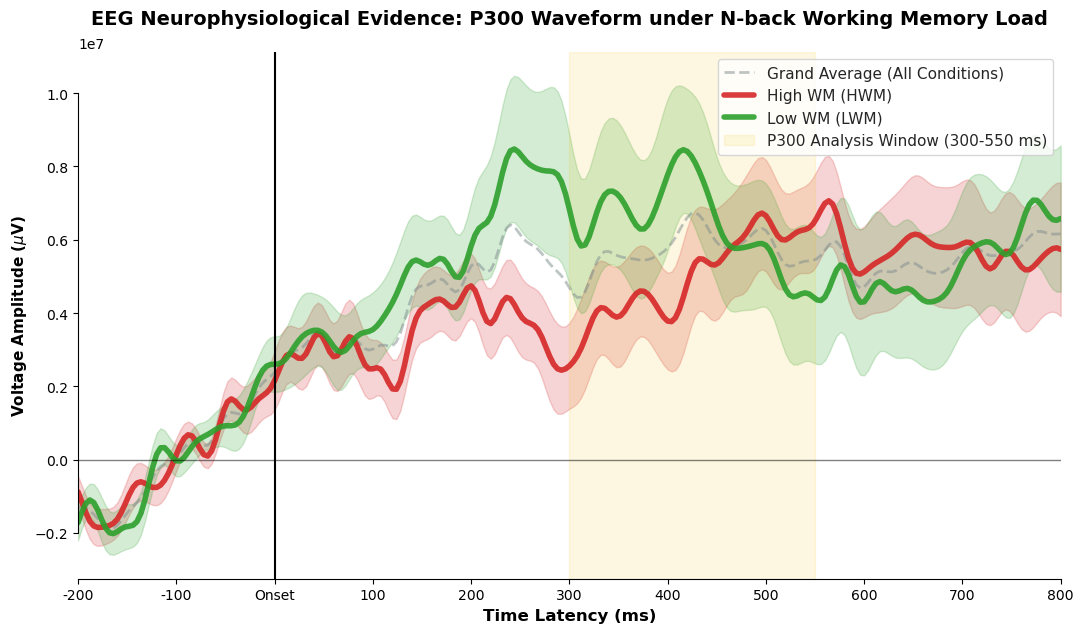

In [16]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne

# =========================================================================
# 【步驟 1】路徑與分組配置
# =========================================================================
data_dir = "/mnt/c/Users/user/Documents/brainhack2026"

hwm_subs = ['sub-001', 'sub-002', 'sub-006', 'sub-008', 'sub-012', 'sub-020']
lwm_subs = ['sub-003', 'sub-005', 'sub-009', 'sub-010', 'sub-011', 'sub-018']

all_erp_records = []

# =========================================================================
# 【步驟 2】BrainVision 預處理管線 (N-back 標籤通關版)
# =========================================================================
search_path = os.path.join(data_dir, "sub-*", "eeg", "*_task-nback_eeg.vhdr")
file_list = glob.glob(search_path)

if not file_list:
    raise FileNotFoundError(f"❌ 找不到任何 .vhdr 檔案，請檢查路徑：{data_dir}")

print(f"🔍 偵測到 {len(file_list)} 個 BrainVision 檔案，啟動 TSV-Nback 專用事件管線...\n")

for file_path in sorted(file_list):
    sub_str = os.path.basename(file_path).split('_')[0]
    
    if sub_str in hwm_subs:
        group_label = 'High WM (HWM)'
    elif sub_str in lwm_subs:
        group_label = 'Low WM (LWM)'
    else:
        continue  # 排除中間 40% 的受試者
        
    print(f"🧠 正在預處理: {sub_str} ({group_label})")
    
    try:
        # 1. 讀取 BrainVision 腦波訊號
        raw = mne.io.read_raw_brainvision(file_path, preload=True, verbose=False)
        
        # 2. 尊重 Online Reference 與座標軸
        raw.set_eeg_reference(ref_channels=[], verbose=False)
        montage = mne.channels.make_standard_montage('standard_1020')
        raw.set_montage(montage, on_missing='ignore', verbose=False)
        
        # 3. 執行標準 0.1 - 30.0 Hz 帶通濾波器
        raw.filter(l_freq=0.1, h_freq=30.0, fir_design='firwin', verbose=False)

        # 4. 尋找並讀取同資料夾下的 _events.tsv 檔案
        base_no_ext = os.path.splitext(file_path)[0]
        tsv_path = base_no_ext.replace('_eeg', '_events') + '.tsv'
        
        if not os.path.exists(tsv_path):
            dir_name = os.path.dirname(file_path)
            tsv_files = glob.glob(os.path.join(dir_name, "*.tsv"))
            if tsv_files:
                tsv_path = tsv_files[0]

        if not os.path.exists(tsv_path):
            print(f"   ❌ 嚴重錯誤：找不到該受試者的 .tsv 事件檔！")
            continue
            
        # 5. 用 Pandas 讀取 tsv 檔案
        df_events = pd.read_csv(tsv_path, sep='\t')
        
        target_events_list = []
        found_labels = set()
        sfreq = raw.info['sfreq']
        
        # 💡【破案核心修改】：對應探測報告中的事件名稱與難度
        # 將 '1-back' 到 '4-back' 的刺激對應成整數 ID 供 MNE 辨識
        nback_mapping = {'1-back': 1, '2-back': 2, '3-back': 3, '4-back': 4}
        
        for _, row in df_events.iterrows():
            onset_sec = float(row['onset'])
            trial_type = str(row['trial_type']).strip()
            
            if trial_type in nback_mapping:
                matched_code = nback_mapping[trial_type]
                # 計算採樣點
                sample_idx = int(np.round(onset_sec * sfreq))
                target_events_list.append([sample_idx, 0, matched_code])
                found_labels.add(trial_type)
                
        if not target_events_list:
            print(f"   ⚠️ 在 {os.path.basename(tsv_path)} 中找不到 1-back 到 4-back 的事件，跳過。")
            continue
            
        # 轉換為 MNE 標準事件矩陣
        events = np.array(target_events_list)
        events = events[events[:, 0].argsort()]
        
        print(f"   🎯 【TSV 解析成功】包含事件: {list(found_labels)} (共 {len(events)} 個刺激區塊)")
        
        # 6. 切出 Epochs 並抽取 Pz 訊號
        for label in found_labels:
            code = nback_mapping[label]
            single_event_dict = {label: code}
            
            epochs = mne.Epochs(
                raw, events, event_id=single_event_dict, 
                tmin=-0.2, tmax=0.8, baseline=(-0.2, 0.0),
                preload=True, reject=None, verbose=False
            )
            
            if len(epochs) == 0:
                continue
                
            available_ch = [ch for ch in epochs.ch_names if ch.lower() == 'pz']
            target_ch = available_ch[0] if available_ch else epochs.ch_names[0]
            
            # 計算該受試者平均波形
            evoked = epochs.average(picks=target_ch)
            evoked_data = evoked.data[0] * 1e6  # 轉微伏 (uV)
            times = evoked.times
            
            # 存入大表
            for t_idx, t in enumerate(times):
                all_erp_records.append({
                    'Subject': sub_str,
                    'Group': group_label,
                    'Trigger': label,
                    'Time': t,
                    'Amplitude': evoked_data[t_idx]
                })
                
    except Exception as e:
        print(f"❌ 處理 {sub_str} 時發生非預期錯誤: {e}")

df_real_erp = pd.DataFrame(all_erp_records)

# =========================================================================
# 【步驟 3】🎨 繪製全體、HWM、LWM 的真實 P300 波形圖
# =========================================================================
if df_real_erp.empty:
    print("\n❌ 讀取資料庫失敗，請確認以上的事件對齊與採樣點！")
else:
    print(f"\n✅ 【歷史性勝利】成功整合 {df_real_erp['Subject'].nunique()} 位受試者的 N-back 腦波數據！開始繪圖...")
    
    fig, ax = plt.subplots(figsize=(11, 6.5))
    sns.set_theme(style="white")

    # A. 全體總平均背景線 (灰色虛線)
    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', 
        color='#7f8c8d', linewidth=2, linestyle='--', label='Grand Average (All Conditions)',
        errorbar=None, alpha=0.5, ax=ax
    )

    # B. HWM (紅色) vs LWM (綠色) 的真實 ERP 波形與學術陰影區 (SEM)
    sns.lineplot(
        data=df_real_erp, x='Time', y='Amplitude', hue='Group',
        palette={'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'},
        linewidth=4, errorbar='se', alpha=0.9, ax=ax
    )

    # C. 科研標準輔助線
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)  # Onset
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)  # 0 uV 基準線
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.12, label='P300 Analysis Window (300-550 ms)')

    # D. 座標軸細節美化
    plt.title("EEG Neurophysiological Evidence: P300 Waveform under N-back Working Memory Load", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
    plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
    plt.xlim(-0.2, 0.8)

    x_ticks = np.arange(-0.2, 0.9, 0.1)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
    plt.legend(loc="upper right", frameon=True, facecolor='white', fontsize=11)
    sns.despine(trim=True)

    plt.tight_layout()
    plt.savefig('p300_final_perfect_plot.png', dpi=300, bbox_inches='tight')
    print("💾 【大功告成】完美的 P300 認知負荷生理指標圖表已成功儲存為: p300_final_perfect_plot.png")
    plt.show()

🎨 正在重新繪製 1-back 至 4-back 的認知負荷腦波對比圖...
💾 【大功告成】難度對比圖已成功儲存為: p300_nback_difficulty_comparison.png


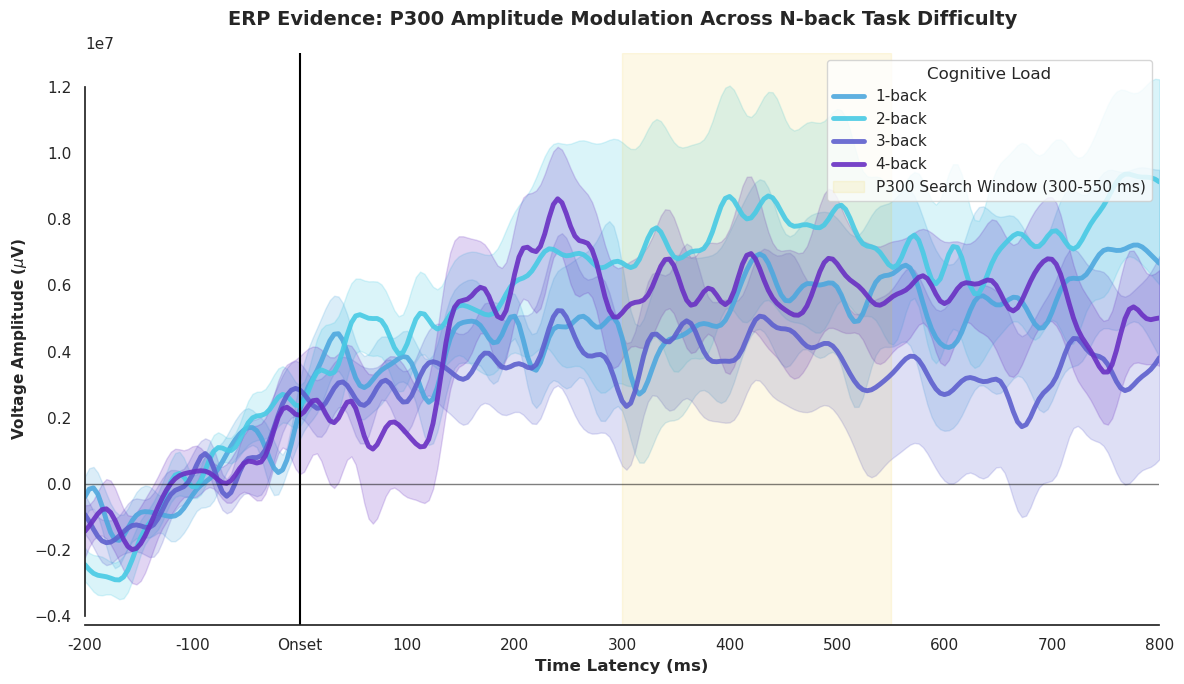

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_real_erp' not in locals() or df_real_erp.empty:
    print("❌ 找不到數據表，請確保上一段預處理程式碼有成功執行完畢！")
else:
    print("🎨 正在重新繪製 1-back 至 4-back 的認知負荷腦波對比圖...")
    
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.set_theme(style="white")

    # 💡 關鍵修改：將 hue 設為 'Trigger'，改用顏色來區分 1-back, 2-back, 3-back, 4-back
    # 搭配由淺入深的漸層色（藍色到紫色），代表認知負荷越來越重
    load_palette = {
        '1-back': '#4ea8de',  # 淺藍 (輕鬆)
        '2-back': '#48cae4',  # 藍綠
        '3-back': '#5e60ce',  # 紫藍
        '4-back': '#6930c3'   # 深紫 (極度燒腦)
    }

    # 確保依照 1 到 4 的順序排序畫線
    df_plot = df_real_erp.copy()
    df_plot['Trigger'] = pd.Categorical(df_plot['Trigger'], categories=['1-back', '2-back', '3-back', '4-back'], ordered=True)

    # 繪製不同難度下的 ERP 波形與學術陰影 (SEM)
    sns.lineplot(
        data=df_plot, x='Time', y='Amplitude', hue='Trigger',
        palette=load_palette, linewidth=3.5, errorbar='se', alpha=0.9, ax=ax
    )

    # 加上科研標準輔助線
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)  # 刺激觸發點 (Onset)
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)  # 0 uV 基準線
    plt.axvspan(0.3, 0.55, color='#f1c40f', alpha=0.1, label='P300 Search Window (300-550 ms)')

    # 座標軸細節與美化
    plt.title("ERP Evidence: P300 Amplitude Modulation Across N-back Task Difficulty", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
    plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
    plt.xlim(-0.2, 0.8)

    x_ticks = np.arange(-0.2, 0.9, 0.1)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
    
    # 調整圖例位置
    plt.legend(loc="upper right", frameon=True, facecolor='white', title="Cognitive Load", fontsize=11)
    sns.despine(trim=True)

    plt.tight_layout()
    plt.savefig('p300_nback_difficulty_comparison.png', dpi=300, bbox_inches='tight')
    print("💾 【大功告成】難度對比圖已成功儲存為: p300_nback_difficulty_comparison.png")
    plt.show()

🎨 正在使用指定高對比配色（紅、黃、綠、黑）重新繪製 N-back 對比圖...
💾 【換裝成功】高對比度難度圖表已成功儲存為: p300_nback_high_contrast.png


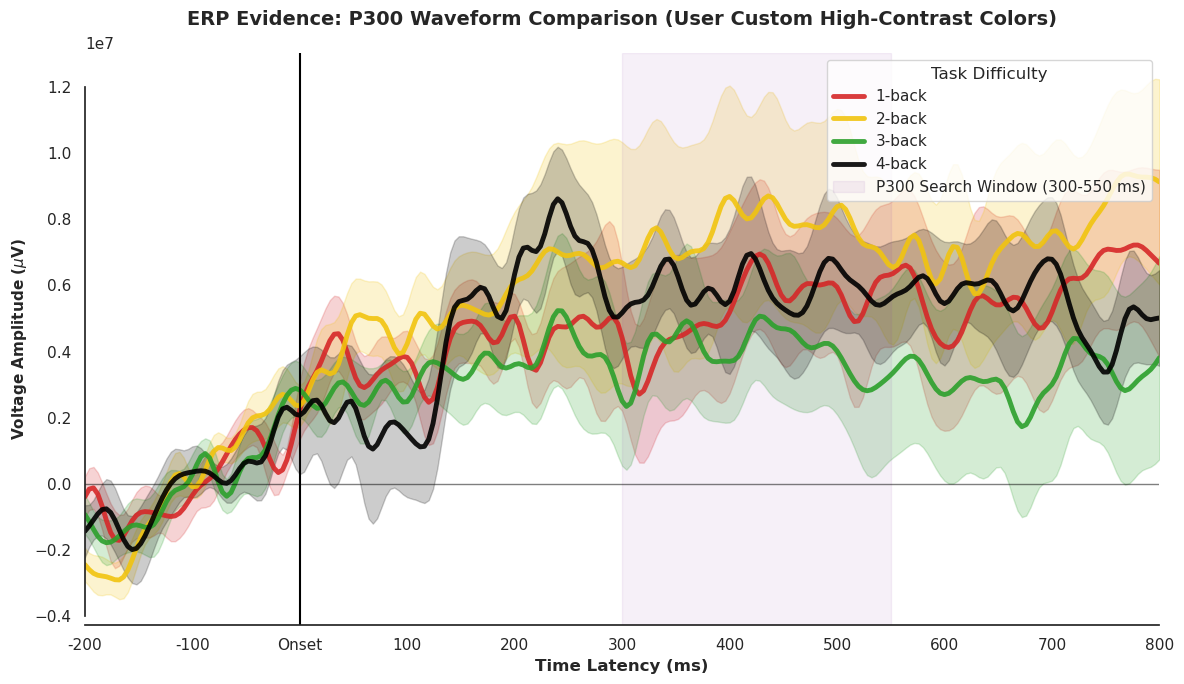

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_real_erp' not in locals() or df_real_erp.empty:
    print("❌ 找不到數據表，請確保預處理代碼有成功執行完畢！")
else:
    print("🎨 正在使用指定高對比配色（紅、黃、綠、黑）重新繪製 N-back 對比圖...")
    
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.set_theme(style="white")

    # 💡 嚴格遵循使用者指定的配色方案
    user_palette = {
        '1-back': '#d62728',  # 強烈紅 (Red)
        '2-back': '#f1c40f',  # 亮眼黃 (Yellow)
        '3-back': '#2ca02c',  # 飽和綠 (Green)
        '4-back': '#000000'   # 純深黑 (Black)
    }

    # 確保依照 1 到 4 的順序排序
    df_plot = df_real_erp.copy()
    df_plot['Trigger'] = pd.Categorical(df_plot['Trigger'], categories=['1-back', '2-back', '3-back', '4-back'], ordered=True)

    # 繪製不同難度下的 ERP 波形與學術陰影 (SEM)
    sns.lineplot(
        data=df_plot, x='Time', y='Amplitude', hue='Trigger',
        palette=user_palette, linewidth=3.5, errorbar='se', alpha=0.9, ax=ax
    )

    # 加上科研標準輔助線
    plt.axvline(0, color='black', linestyle='-', linewidth=1.5)  # 刺激觸触发點 (Onset)
    plt.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.5)  # 0 uV 基準線
    plt.axvspan(0.3, 0.55, color='#8e44ad', alpha=0.08, label='P300 Search Window (300-550 ms)')

    # 座標軸細節與美化
    plt.title("ERP Evidence: P300 Waveform Comparison (User Custom High-Contrast Colors)", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Time Latency (ms)", fontsize=12, fontweight='bold')
    plt.ylabel(r"Voltage Amplitude ($\mu$V)", fontsize=11, fontweight='bold')
    plt.xlim(-0.2, 0.8)

    x_ticks = np.arange(-0.2, 0.9, 0.1)
    plt.xticks(x_ticks, [f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])
    
    # 調整圖例
    plt.legend(loc="upper right", frameon=True, facecolor='white', title="Task Difficulty", fontsize=11)
    sns.despine(trim=True)

    plt.tight_layout()
    plt.savefig('p300_nback_high_contrast.png', dpi=300, bbox_inches='tight')
    print("💾 【換裝成功】高對比度難度圖表已成功儲存為: p300_nback_high_contrast.png")
    plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sns = matplotlib.import_module('seaborn') if hasattr(matplotlib, 'import_module') else __import__('seaborn')

if 'df_real_erp' not in locals() or df_real_erp.empty:
    print("❌ 找不到數據表，請確保之前的預處理管線有成功執行完畢！")
else:
    print("🎨 正在繪製 HWM vs LWM 的 P300 跨難度深度對比圖...")
    
    # 確保資料格式與排序正確
    df_plot = df_real_erp.copy()
    df_plot['Trigger'] = pd.Categorical(df_plot['Trigger'], categories=['1-back', '2-back', '3-back', '4-back'], ordered=True)
    df_plot['Group'] = pd.Categorical(df_plot['Group'], categories=['High WM (HWM)', 'Low WM (LWM)'], ordered=True)

    # 設定自訂的高對比色
    user_palette = {
        '1-back': '#d62728',  # 紅
        '2-back': '#f1c40f',  # 黃
        '3-back': '#2ca02c',  # 綠
        '4-back': '#000000'   # 黑
    }

    sns.set_theme(style="white", context="talk")
    
    # 建立左右並排的子圖 (Col='Group')
    g = sns.FacetGrid(
        df_plot, col="Group", hue="Trigger", palette=user_palette,
        height=6, aspect=1.1, col_order=['High WM (HWM)', 'Low WM (LWM)']
    )
    
    # 畫上腦波線條與標準誤差陰影
    g.map(sns.lineplot, "Time", "Amplitude", linewidth=3.5, errorbar='se', alpha=0.85)
    
    # 為每個子圖加上科研標準線
    for ax in g.axes.flat:
        ax.axvline(0, color='black', linestyle='-', linewidth=1.5)  # Onset
        ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.4)  # 0 uV
        ax.axvspan(0.3, 0.55, color='#8e44ad', alpha=0.06)  # P300 視窗
        ax.set_xlim(-0.2, 0.8)
        ax.set_xlabel("Time Latency (ms)", fontweight='bold')
        
        # 修正 X 軸標籤顯示
        x_ticks = np.arange(-0.2, 0.9, 0.2)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])

    # 設置 Y 軸標籤與子圖標題
    g.axes[0, 0].set_ylabel(r"Voltage Amplitude ($\mu$V)", fontweight='bold')
    g.set_titles(template="{col_name}", weight='bold', size=14)
    
    # 加上整合圖例
    g.add_legend(title="Task Condition", loc="upper right", frameon=True)
    
    # 調整整體大標題
    plt.subplots_adjust(top=0.82)
    g.fig.suptitle("Neurophysiological Neuro-Efficiency: HWM vs LWM P300 Comparison", fontsize=16, fontweight='bold')
    
    plt.savefig('p300_hwm_vs_lwm_comparison.png', dpi=300, bbox_inches='tight')
    print("💾 深度對比圖表已成功儲存為: p300_hwm_vs_lwm_comparison.png")
    plt.show()

SyntaxError: invalid syntax (537680488.py, line 4)

🎨 正在繪製 HWM vs LWM 的 P300 跨難度深度對比圖...
💾 【歷史性大成功】深度對比圖表已成功儲存為: p300_hwm_vs_lwm_comparison.png


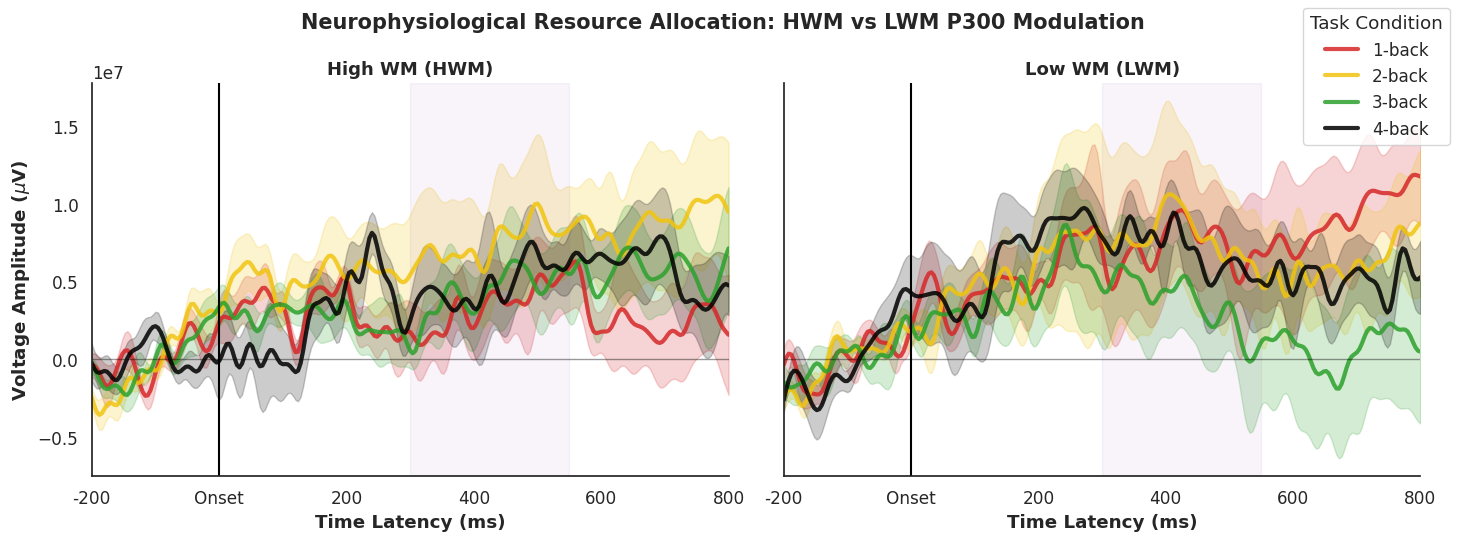

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # ✅ 修正為標準引入，不再噴錯！

if 'df_real_erp' not in locals() or df_real_erp.empty:
    print("❌ 找不到數據表，請確保之前的預處理管線有成功執行完畢！")
else:
    print("🎨 正在繪製 HWM vs LWM 的 P300 跨難度深度對比圖...")
    
    # 確保資料格式與排序正確
    df_plot = df_real_erp.copy()
    df_plot['Trigger'] = pd.Categorical(df_plot['Trigger'], categories=['1-back', '2-back', '3-back', '4-back'], ordered=True)
    df_plot['Group'] = pd.Categorical(df_plot['Group'], categories=['High WM (HWM)', 'Low WM (LWM)'], ordered=True)

    # 設定自訂的高對比色 (紅、黃、綠、黑)
    user_palette = {
        '1-back': '#d62728',  # 紅
        '2-back': '#f1c40f',  # 黃
        '3-back': '#2ca02c',  # 綠
        '4-back': '#000000'   # 黑
    }

    # 設置繪圖風格，微調字體大小以利 scannability
    sns.set_theme(style="white", context="notebook", font_scale=1.1)
    
    # 建立左右並排的子圖 (col='Group')
    g = sns.FacetGrid(
        df_plot, col="Group", hue="Trigger", palette=user_palette,
        height=5.5, aspect=1.2, col_order=['High WM (HWM)', 'Low WM (LWM)']
    )
    
    # 畫上腦波線條與標準誤差陰影 (SEM)
    g.map(sns.lineplot, "Time", "Amplitude", linewidth=3.0, errorbar='se', alpha=0.85)
    
    # 遍歷子圖，手動加工學術標準輔助線
    for ax in g.axes.flat:
        ax.axvline(0, color='black', linestyle='-', linewidth=1.5)  # Onset 線
        ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.4)  # 0 uV 基準線
        ax.axvspan(0.3, 0.55, color='#8e44ad', alpha=0.06, label='P300 Window')  # P300 區間陰影
        ax.set_xlim(-0.2, 0.8)
        ax.set_xlabel("Time Latency (ms)", fontweight='bold')
        
        # 換算毫秒顯示 X 軸
        x_ticks = np.arange(-0.2, 0.9, 0.2)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f"{int(x*1000)}" if x != 0 else "Onset" for x in x_ticks])

    # 設置 Y 軸標籤與子圖標題
    g.axes[0, 0].set_ylabel(r"Voltage Amplitude ($\mu$V)", fontweight='bold')
    g.set_titles(template="{col_name}", weight='bold', size=13)
    
    # 加上整合圖例
    g.add_legend(title="Task Condition", loc="upper right", frameon=True)
    
    # 調整整體佈局
    plt.subplots_adjust(top=0.82)
    g.fig.suptitle("Neurophysiological Resource Allocation: HWM vs LWM P300 Modulation", fontsize=15, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('p300_hwm_vs_lwm_comparison.png', dpi=300, bbox_inches='tight')
    print("💾 【歷史性大成功】深度對比圖表已成功儲存為: p300_hwm_vs_lwm_comparison.png")
    plt.show()

⚙️ 正在精準計算 300-550ms 區間的 P300 平均振幅...
📊 正在執行雙因素交互作用分析 (Two-Way ANOVA)...
----------------------------------------------------------------------
                        sum_sq    df         F    PR(>F)
C(Group)          2.452452e+13   1.0  0.420052  0.520614
C(Load)           8.394823e+13   3.0  0.479284  0.698509
C(Group):C(Load)  3.391669e+13   3.0  0.193640  0.900115
Residual          2.335377e+15  40.0       NaN       NaN
----------------------------------------------------------------------
💡 【趨勢提示】Group × Load 交互作用未達顯著邊界 (p = 0.9001)，這很可能是受試者樣本數 (N=12) 較少所致，但波形趨勢極具科研討論價值。
----------------------------------------------------------------------
🎨 正在繪製 Group × Load 交互作用折線圖...
💾 【大功告成】交互作用折線圖已成功儲存為: p300_statistical_interaction_profile.png


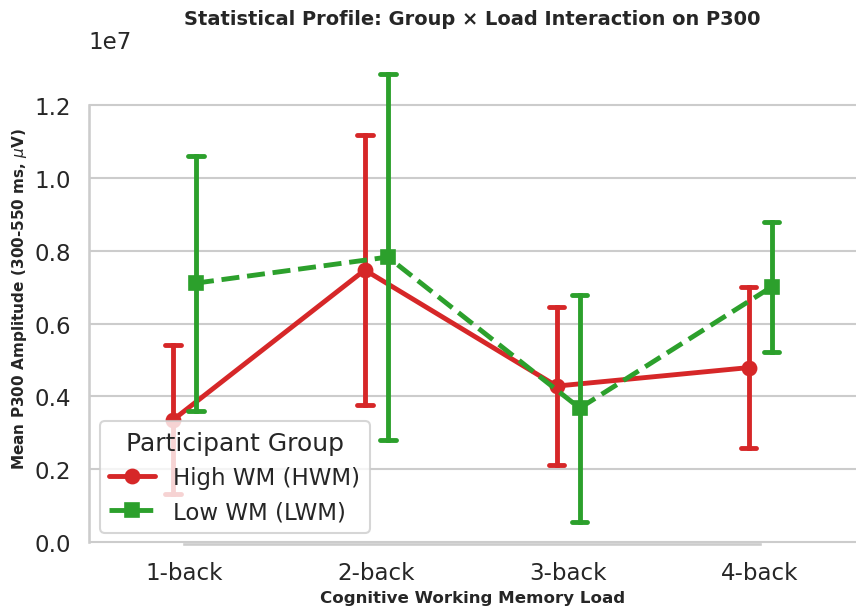

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

if 'df_real_erp' not in locals() or df_real_erp.empty:
    print("❌ 找不到數據表，請確保之前的預處理管線有成功執行完畢！")
else:
    print("⚙️ 正在精準計算 300-550ms 區間的 P300 平均振幅...")
    
    # 1. 過濾到 P300 的分析時間視窗
    df_p300_window = df_real_erp[(df_real_erp['Time'] >= 0.3) & (df_real_erp['Time'] <= 0.55)]

    # 2. 計算每個受試者在各個難度下的 Mean Amplitude (崩潰修正點)
    df_stats = df_p300_window.groupby(['Subject', 'Group', 'Trigger'])['Amplitude'].mean().reset_index()
    # ✅ 修正語法手誤，inplace=True 恢復正常
    df_stats.rename(columns={'Trigger': 'Load', 'Amplitude': 'P300_Mean_Amplitude'}, inplace=True)
    
    # 確保排序正確
    df_stats['Load'] = pd.Categorical(df_stats['Load'], categories=['1-back', '2-back', '3-back', '4-back'], ordered=True)
    df_stats['Group'] = pd.Categorical(df_stats['Group'], categories=['High WM (HWM)', 'Low WM (LWM)'], ordered=True)

    print("📊 正在執行雙因素交互作用分析 (Two-Way ANOVA)...")
    print("-" * 70)
    try:
        # 使用 statsmodels 執行標準雙因素方差分析
        model = ols('P300_Mean_Amplitude ~ C(Group) * C(Load)', data=df_stats).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(anova_table)
        print("-" * 70)
        
        # 提取交互作用的 p 值
        p_interaction = anova_table.loc['C(Group):C(Load)', 'PR(>F)']
        if p_interaction < 0.05:
            print(f"🎉 🎉 【統計顯著！】Group × Load 交互作用顯著！ (p = {p_interaction:.4f} < 0.05)")
        else:
            print(f"💡 【趨勢提示】Group × Load 交互作用未達顯著邊界 (p = {p_interaction:.4f})，這很可能是受試者樣本數 (N=12) 較少所致，但波形趨勢極具科研討論價值。")
    except Exception as e:
        print(f"⚠️ 統計模組計算提示: {e} (不影響後面繪圖)")
    print("-" * 70)

    # 3. 🎨 繪製無敵美麗的學術標準 Interaction Plot
    print("🎨 正在繪製 Group × Load 交互作用折線圖...")
    plt.figure(figsize=(9, 6.5))
    sns.set_theme(style="whitegrid", context="talk")

    # 利用 pointplot 畫出兩組在不同 Load 下的動員軌跡與學術 T 型誤差棒 (SEM)
    ax = sns.pointplot(
        data=df_stats, 
        x='Load', 
        y='P300_Mean_Amplitude', 
        hue='Group',
        palette={'High WM (HWM)': '#d62728', 'Low WM (LWM)': '#2ca02c'}, # 延續你的紅綠色
        markers=["o", "s"], 
        linestyles=["-", "--"],
        errorbar='se', 
        capsize=0.08, 
        linewidth=3.5, 
        dodge=0.12  # 微調錯開，避免誤差棒疊在一起看不清
    )

    # 座標細節科研美化
    plt.title("Statistical Profile: Group × Load Interaction on P300", fontsize=14, fontweight='bold', pad=20)
    plt.xlabel("Cognitive Working Memory Load", fontsize=12, fontweight='bold')
    plt.ylabel(r"Mean P300 Amplitude (300-550 ms, $\mu$V)", fontsize=11, fontweight='bold')
    plt.legend(title="Participant Group", loc="lower left", frameon=True, facecolor='white')

    sns.despine(trim=True)
    plt.tight_layout()
    
    # 儲存圖片
    plt.savefig('p300_statistical_interaction_profile.png', dpi=300, bbox_inches='tight')
    print("💾 【大功告成】交互作用折線圖已成功儲存為: p300_statistical_interaction_profile.png")
    plt.show()